-----
# AM10: Computing for Science and Engineering - Module 2

## Lab 05: Numerical Differentiation
-----

### Learning objectives:

- Implementing numerical differentiation

- Applications numerical differentiation: Derivatives of known and unknown (data) functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Implementing the central difference formula for numerical differentiation

In the following exercise, we will implement a Python function that performs numerical differentiation using the central difference formula. As a reminder, the central difference formula is given by the following expression.

$$f'(n) = \frac{f(n+1)-f(n-1)}{2(dx)}$$

Before we start writing code, it is often instructive to think in terms of psuedocode and note down the steps involved in performing the necessary tasks. 

Think along the lines of what inputs does one need to apply the above formula? Once we know the inputs what needs to be done with them? What should be outputted in the end?

----------
### *Breakout Room Discussion (10 mins)*

Discuss and write down the psuedocode for creating the function described above.

----------

### *Notes*

We clearly need to know the value of the function $f(x)$ at points separated by $dx$ (implying that we also need to know the value of $dx$). 

Once we have all the values of $f(x)$, we can calculate $f'(x)$ by repeatedly applying the above formula while we shift the set of points on which it is applied. So, we need to know how many points are there in the *vectorized* form of the function $f(x)$. Let's call it `fx`. 

To perform the same task repeatedly for a fixed number of times, we need a `for` loop. So, our implementation will essentially have the above formula in code inside a `for` loop. 

You have also seen how we can improve the calculation of the end points using extrapolation. So, putting all of this together, we can note down the following steps in pseudocode.

An example of possible psuedocode:
1. Input `fx` (the discretized function to be differentiated) and `dx` (discretization step or resolutionT)
2. Find the number of points, `nx`, in the discretized function `fx`
3. Initialize the output array to be the same number of points `nx`
4. Start a `for` loop to iterate over all `nx` starting from 1 to `nx-1`
5. Inside the loop: 
    1. Calculate: $f'(n) = \left [f(n+1)-f(n-1)\right] / 2(dx)$
6. Calculate $f'$ at end points, `0` and `nx` using extrapolation
7. Output (return) the result `dfdx`

------------
### *Main Room Exercise 1*

Complete the code below to implement a function for calculating the numerical derivative using the central difference formula. The input to these functions is an array, `fx`, that contains the discritized form of the function you want to differentiate and the numerical resolution `dx`.

In [2]:
def central_diff(fx, dx):   

    ''' This function calculates the numerical first derivative of an inputted function 
        in the form of a vector using the central difference formula.
        Input:
           fx : Discretized function [array]
           dx : Resolution [scalar]
        Output: 
           d1_cent : First derivative of function using central difference [array]. 
    '''

    # Find the size of inputted function fx
    nx = len(fx)
    
    # Initialize the output array to zeros with the same size as the inputted array
    d1_cent=np.zeros(nx)
    
    # Generate the central difference array at all points except the first and last
    for n in range (1, nx-1):
        d1_cent[n] = (fx[n+1] - fx[n-1]) / (2.0 * dx)
            
    # Improve end points by first-order extrapolation
    d1_cent[0] = 2 * d1_cent[1] - d1_cent[2]
    d1_cent[nx - 1] = 2 * d1_cent[nx - 2] - d1_cent[nx - 3]

    # return the output
    return d1_cent

----------
## Calculating first derivative of a known function

Now that we have written a function to calculate the first derivative, we need to test how well it works. In the exercise below, we will use the above function to calculate the first derivative a known mathematical functions. 

Let's again first think of what we need in order to test our function. 

We clearly need to know $f(x)$. But knowing $f(x)$ alone is not enough. We will also need $dx$ and the range in which we wish to calculate the derivative. 

Once we have all the above information, we will need to discretize $f(x)$ to create the vector `fx`. 

In order to discretize $f(x)$, we can create a linear vector of $x$ (let's give it a variable name `x`) and simply calculate the values of $f(x)$ at each element of `x`. To calculate the values of $f(x)$, we can define a function that simply takes in `x` and returns output of the expression of $f(x)$.

Then we simply input `fx` and `dx` to our function `central_diff`.

-----------
### *Main Room Exercise 2*

Complete the code below to calculate the first derivative of $f(x) = x^3\cos{x}$ in the range $0\leq x\leq 20$ with $dx=1$. Also, calculate the first derivative using the analytical expression and plot both the numerical and analytical derivatives on a figure.

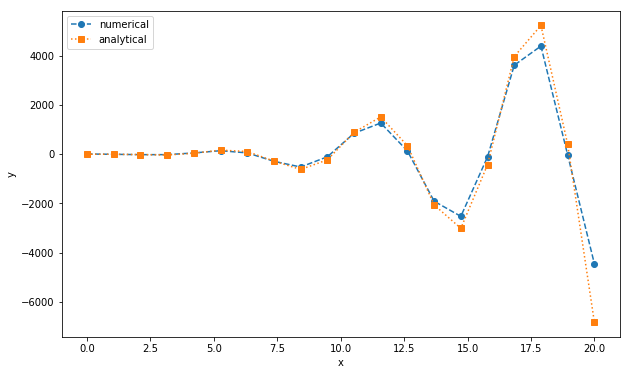

In [3]:
# Define f(x)
def fofx(x):
    y = x**3 * np.cos(x)
    return y

# generate the vector x
xmin = 0.0
xmax = 20.0
dx = 1
nx = int((xmax - xmin) / dx)
x = np.linspace(xmin, xmax, nx)

# Evaluate f(x) to generate fx 
fx = fofx(x)

# Calculate first derivative numerically
dfdx1 = central_diff(fx, dx)

# Calculate first derivative analytically
dfdx2 = 3 * x**2 * np.cos(x) - x**3 * np.sin(x)

# Plot the first derivatives on same figure
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.plot(x, dfdx1, 'o--',label='numerical')
ax1.plot(x, dfdx2, 's:', label='analytical')
ax1.legend()
plt.show(fig1)

---------
### *Main Room Exercise 3*

Let's say we want to calculate the derivative of $f(x)$ for several different values of $dx$ and plot all of the results on the same figure. Let's discuss how you would do this and then implement in code.

Use $dx = 1$, $0.5$, and $0.1$. Also, calculate the first derivative using the analytical expression using the vector `x` created using the last value of `dx` (*i.e.* $dx=0.1$). Plot all the curves on the same figure.


#### Psuedocode:
There are of course several ways to do this. Below is the psuedocode for one way.

1. Required: `fx`, all values of `dx`, range for calculating `dfdx`
2. Create empty figure for plotting all `dfdx`
3. Start a `for` loop to iterate over all values of `dx`
4. Inside the loop:
    1. Create the vector for `x` using the given range
    2. Evaluate $f(x)$ using `x` to generate the array `fx`
    3. Call the function `central_diff` with inputs `fx` for current `dx`
    4. Add `dfdx` to the figure
5. Calculate analytical derivative of $f(x)$ 
6. Add it to the plot
7. Add legend and show the figure

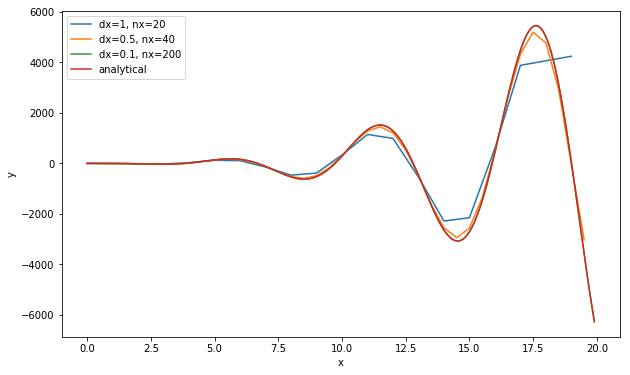

In [4]:
# Create a list of all values of dx
dx = [1, 0.5, 0.1]

# Define constants
xmin = 0.0
xmax = 20.0

# Setup figure for the plot
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.set_xlabel('x')
ax2.set_ylabel('y')

# Write for loop to repeat through all values of dx
for i in range (0, len(dx)):
    
    # generate the vector x
    x = np.arange(xmin, xmax, dx[i])
    nx = len(x)
    
    # Evaluate f(x) to generate fx 
    fx = fofx(x)

    # Calculate first derivative numerically
    dfdx1 = central_diff(fx, dx[i])

    # Plot the first derivatives on same figure
    ax2.plot(x, dfdx1, label='dx='+str(dx[i])+', nx='+str(nx))
    
# Calculate first derivative analytically for nx=100 points
dfdx2 = 3 * x**2 * np.cos(x) - x**3 * np.sin(x)

# Add analytical derivative to plot
ax2.plot(x, dfdx2, label='analytical')
ax2.legend()
plt.show(fig2)

------------
## Calculating derivative of an unknown (data) function

What if we want to calculate the derivative of some data which is of an unkown functional form? 

Think of what the steps might be to do so? Could we use the function `central_diff` to do this? 

Instead of a known functional form, $f(x)$, if we already have a set of points for which we want to calculate the numerical derivative then we essentially are still following the same steps that we outined in the pseudocode above. The only difference being that we no longer have a continuous function to discretize. We simply use the separation between consecutive points of the independent variable to find the value of `dx`. 

Let's explore this in the exercise below.

-------------
### *Main Room Exercise 4*

Calculate the numerical derivate of the data in the file `AM10-Lab-05-fxdata.txt`. First, plot the data in a figure. Then use the function you wrote earlier, `central_diff`, to calculate the derivative. Lastly, plot the data and its derivate in a figure.

-------------
#### Only for Google Colab users
For those using Google Colab, the lines of code below can be used to mount your Google Drive where you can download the data file. Then you can use the usual functions to load the data into the notebook.

```python
# Load the Drive helper and mount
from google.colab import drive
    
# This will prompt for authorization
drive.mount('/content/drive')
```
-------------

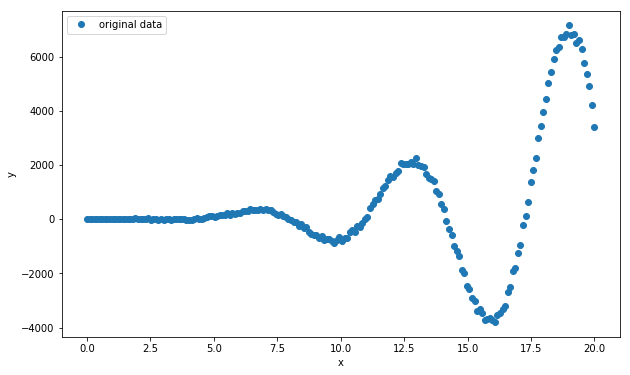

In [5]:
# Load the data into variables
xdat, fxdat = np.loadtxt('AM10-Lab-05-fxdata.txt')

# Plot the data on a figure
fig3, ax3 = plt.subplots(figsize=(10, 6))
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.plot(xdat, fxdat, 'o', label='original data')
ax3.legend()
plt.show(fig3)

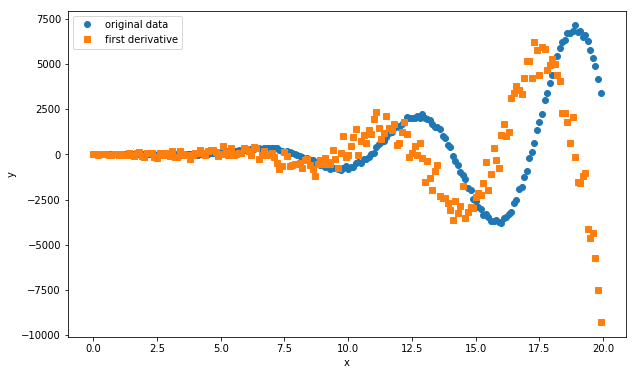

In [6]:
# Calculate the value of dx
dx = xdat[1] - xdat[0]

# Compute the first derivate of the data
dfdx3 = central_diff(fxdat, dx)

# Plot the data and its first derivatives on same figure
fig4, ax4 = plt.subplots(figsize=(10, 6))
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.plot(x, fxdat, 'o', label='original data')
ax4.plot(x, dfdx3, 's',label='first derivative')
ax4.legend()
plt.show(fig4)

***Note:*** The original data you read from the file was the obtained by adding some linear random noise to the same function, $f(x) = x^3\cos{x}$, you used in the first few exercises. Notice that by taking the numerical derivative we have Inadvertently increased the noise. This is because we have taken the difference between two noisy values and divided that by a small number, as a result, enhancing the noise.

--------------
## Application of Taylor expansion: Object falling with drag


The following is a simple application involving fall with drag, and taking advantage of the facts that velocity $v(t)$ and acceleration $a(t)$ are the first and second derivatives, resperctively, of the position $x(t)$:

$$v(t) = \frac{dx}{dt}, \; \; \; a(t) = \frac{dv}{dt} = \frac{d^2 x}{dt^2}$$

We will take the force $F$ acting on a falling body of mass $m$ along the vertical $x$-axis to be:

$$ F = -mg + \frac{1}{2} \gamma [v(t)]^2$$

where $g$ is the constant of gravity and $\gamma$ is the coefficient of drag [the last term is due to drag, which is proportional to the velocity $v(t)$ squared]. Since the force is given by Newton's Second Law as: $F=m a(t)$, where $a(t)$ is the instantaneous acceleration, we then have:

$$ a(t) = -g + \frac{\gamma}{2 m} [v(t)]^2$$

We can use the Taylor expansion to get the position $x(t)$ at every moment of time, given the intitial position $x(0)=x_0$ and velocity $v(0)=v_0$:

$$x(t+ dt) = x(t) + v(t) dt + \frac{1}{2} a(t) (dt)^2$$

by constantly updating the position, velocity and acceleration, starting at $t=0$, and using small increments of time $dt$. Using again the Taylor expansion, but keeping only up to first-order terms in $dt$, the velocity is given by:

$$v(t+dt) = v(t) + a(t) dt$$

###  Pseudocode

The above expressions lead to the following algorithm for the time propagation of position, velocity, acceleration:

\begin{eqnarray}
(0) & \; & {\rm Initialize}: \; t=0 \to a(0)=-g, \; v(0) = v_0, \; x(0) = x_0 \\
(1) & \; & \; \; \; a(t) = -g + \frac{\gamma}{2 m} [v(t)]^2 \\
(2) & \; & \; \; \; x(t+dt) = x(t) + v(t) dt + \frac{1}{2} a(t) (dt)^2 \\
(3) & \; & \; \; \; v(t+dt) = \frac{x(t+dt) -x(t)}{dt} \\
(4) & \; & \; \; \; {\rm SET} \; t \to (t+dt), \; \; \; {\rm GOTO} \;  (1) \\
\end{eqnarray}

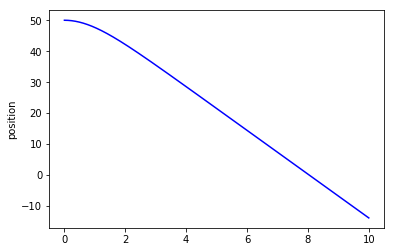

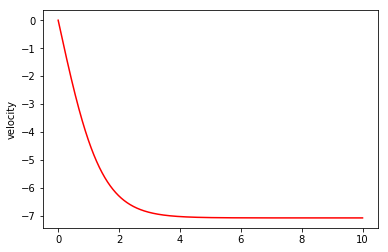

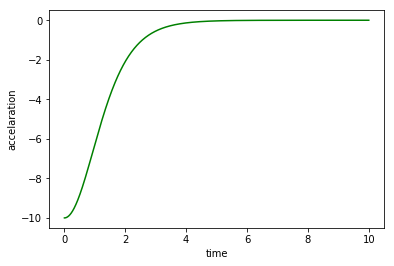

In [7]:
# Define constants
mass = 5.0
g = 10.0
gam = 1.0
gamovm = gam/mass

# Define variables
tmax = 10
nt = 1000
t = np.linspace(0, tmax, nt)
dt = t[1]-t[0]
dt2 = dt**2

# Initialize variables
x = np.zeros(nt)
v = np.zeros(nt)
a = np.zeros(nt)

# Define initial conditions
x[0] = 50
v[0] = 0.0

# Loop for the time propagation of position, velocity, acceleration
for n in range(nt-1):
    # acceleration
    a[n] = -g + gamovm * v[n]**2
    # position
    x[n+1] = x[n] + v[n] * dt + 0.5 * a[n] * dt2
    # velocity
    v[n+1] = (x[n+1] - x[n]) / dt

# Plot results
plt.plot(t, x, 'b')
plt.ylabel('position')
plt.show()
plt.plot(t, v, 'r')
plt.ylabel('velocity')
plt.show()
plt.plot(t, a, 'g')
plt.ylabel('accelaration')
plt.xlabel('time')
plt.show()

### *Breakout Room Discussion (10 mins)*

Notice from the above plot of velocity and acceleration that as the object falls, after some time it reaches a state where the velocity remains constant, i.e., acceleration aprroaches zero. This is known as the *terminal velocity*. Let's say you wanted to determine the terminal velocity that this object attains. Discuss and try modifying the code (copy the code to a new cell before modifying) using a `while` loop to allow propagating until the acceleration is withing a certain tolerance (say $10^{-3}$) of zero. Print out the values of the position, velocity, acceleration, and time after the code exits the loop.

At terminal velocity:
position = 4.124062
velocity = -7.070721
acceleration = -0.000995
time = 7.460000


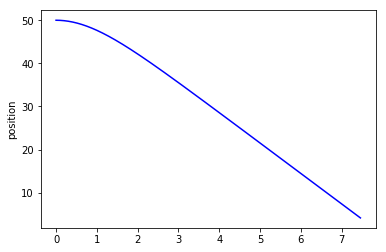

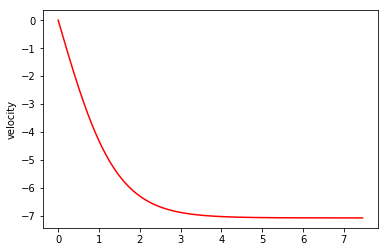

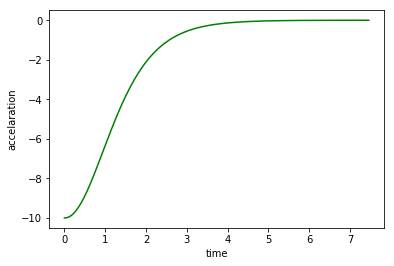

In [8]:
# Define constants
mass = 5.0
g = 10.0
gam = 1.0
gamovm = gam / mass
tol = 1e-3
err = 1 / tol

# Define initial conditions
x0 = 50
v = 0.0
t = 0

# Define time step
dt = 0.01
dt2 = dt**2

# Define empty lists to hold variables
pos = [x0]
vel = [0]
acc = [-g]
time = [0]

# Loop for the time propagation of position, velocity, acceleration
while err > tol:
    # acceleration
    a = -g + gamovm * v**2
    # position
    x1 = x0 + v * dt + 0.5 * a * dt2
    # velocity
    v = (x1 - x0) / dt
    # error
    err = np.absolute(a)
    # update position
    x0 = x1
    # update time
    t = t + dt
    # append lists
    acc.append(a)
    vel.append(v)
    pos.append(x1)
    time.append(t)

# Print out results
print('At terminal velocity:')
print('position =', '{:f}'.format(x1))
print('velocity =', '{:f}'.format(v))
print('acceleration =', '{:f}'.format(a))
print('time =', '{:f}'.format(t))    

# Plot results
plt.plot(time, pos, 'b')
plt.ylabel('position')
plt.show()
plt.plot(time, vel, 'r')
plt.ylabel('velocity')
plt.show()
plt.plot(time, acc, 'g')
plt.ylabel('accelaration')
plt.xlabel('time')
plt.show()